Journal used to examine and validate the info pulled for each protein.

### Initialization

In [30]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt


# choose file
file_path = "../data/3_organized/protein_info_HE.tsv"
raw_data_dir = "../data/1_raw/he_proteome/"

# check working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/keitaichii/Programming/RESEARCH/TORII/tardigrade_proteome_KG/notebooks


In [2]:
# convert to DF 
raw_df = pd.read_csv(file_path, sep='\t', dtype=str)

# show first lines of file
print(raw_df.head())

   UniProt_ID     NCBI_ID                                           Sequence  \
0  A0A1W0XE67  OQV25661.1  MLNNSYNLSFTNISYDAGMFKLPTFIRVTTYTGCVILFLATLFNIL...   
1  A0A9X6RKV7  OWA51663.1  MSSENSTANYNGSPNSEKINHLAGTEDAVMQGNANPVGELSRSFSV...   
2  A0A1W0XAQ4  OQV20927.1  MTGRGKGGKGLGKGGAKRHRKVLRDNIQGITKPAIRRLARRGGVKR...   
3  A0A1W0X7P1  OQV23400.1  MARGIYVNSEVAKAVHRLRRVENKTHGEIGRYFGKTESWARMVLLL...   
4  A0A1W0WZI5  OQV20621.1  MNGCDSKIYQTIILEFVGFLPLPTNQLNIGVQNVYRSKLISLVRAS...   

  GeneID                                              GO_mf  \
0    NaN  GO:0004930 - F:G protein-coupled receptor acti...   
1    NaN                                                NaN   
2    NaN  GO:0003677 - F:DNA binding;GO:0046982 - F:prot...   
3    NaN                GO:0003676 - F:nucleic acid binding   
4    NaN                                                NaN   

                                              GO_cc GO_bp Pfam_domains  \
0                    GO:0005886 - C:plasma membrane   NaN      PF0

### GO Terms

In [19]:
# isolate GO-term related columns
go_term_columns = [col for col in raw_df.columns if 'GO:' in str(raw_df[col].dropna().astype(str).values).upper()]
# make a new DF with only GO-term columns
go_df = raw_df[go_term_columns]
# show first lines of GO-term DF
print(go_df.head())
# count number of rows total
print(f"Total number of rows: {len(go_df)}")

                                               GO_mf  \
0  GO:0004930 - F:G protein-coupled receptor acti...   
1                                                NaN   
2  GO:0003677 - F:DNA binding;GO:0046982 - F:prot...   
3                GO:0003676 - F:nucleic acid binding   
4                                                NaN   

                                              GO_cc GO_bp  
0                    GO:0005886 - C:plasma membrane   NaN  
1                          GO:0005737 - C:cytoplasm   NaN  
2  GO:0000786 - C:nucleosome;GO:0005634 - C:nucleus   NaN  
3                            GO:0005634 - C:nucleus   NaN  
4                           GO:0016020 - C:membrane   NaN  
Total number of rows: 20734


In [25]:
# count the number of NaN entries in each GO-term column
go_mf_nan_counts = 0
go_cc_nan_counts = 0
go_bp_nan_counts = 0
all_go_nan_counts = 0

for idx, row in go_df.iterrows():
    curr_row = 0
    for col in go_term_columns:
        if 'GO_mf' in col and pd.isna(row[col]):
            go_mf_nan_counts += 1
            curr_row += 1
        elif 'GO_cc' in col and pd.isna(row[col]):
            go_cc_nan_counts += 1
            curr_row += 1
        elif 'GO_bp' in col and pd.isna(row[col]):
            go_bp_nan_counts += 1
            curr_row += 1
    if curr_row == 3:
        all_go_nan_counts += 1


# present results as raw value and percentage
total_rows = len(go_df)
print(f"GO Term NaN Counts out of {total_rows} proteins:")
print(f"    GO Molecular Function NaN count: {go_mf_nan_counts} ({(go_mf_nan_counts / total_rows) * 100:.2f}%)")
print(f"    GO Cellular Component NaN count: {go_cc_nan_counts} ({(go_cc_nan_counts / total_rows) * 100:.2f}%)")
print(f"    GO Biological Process NaN count: {go_bp_nan_counts} ({(go_bp_nan_counts / total_rows) * 100:.2f}%)")
print(f"    GO terms with NaN in all three categories: {all_go_nan_counts} ({(all_go_nan_counts / total_rows) * 100:.2f}%)")

GO Term NaN Counts out of 20734 proteins:
    GO Molecular Function NaN count: 10924 (52.69%)
    GO Cellular Component NaN count: 9483 (45.74%)
    GO Biological Process NaN count: 13332 (64.30%)
    GO terms with NaN in all three categories: 7190 (34.68%)


In [28]:
# distribution of which GO terms are most/least common in each category
def isolate_go_term_id(go_cell_string):
    go_cell_string = str(go_cell_string)
    # split by ;
    go_terms = go_cell_string.split(';')
    # take only the GO term IDs (first 7 characters)
    go_term_ids = [term.strip()[:10] for term in go_terms if term.strip().startswith('GO:')]
    return go_term_ids

go_mf_dict = {}
go_cc_dict = {}
go_bp_dict = {}

for idx, row in go_df.iterrows():
    for col in go_term_columns:
        if not pd.isna(row[col]):
            go_term_ids = isolate_go_term_id(row[col])
            if 'GO_mf' in col:
                for go_id in go_term_ids:
                    if go_id in go_mf_dict:
                        go_mf_dict[go_id] += 1
                    else:
                        go_mf_dict[go_id] = 1
            elif 'GO_cc' in col:
                for go_id in go_term_ids:
                    if go_id in go_cc_dict:
                        go_cc_dict[go_id] += 1
                    else:
                        go_cc_dict[go_id] = 1
            elif 'GO_bp' in col:
                for go_id in go_term_ids:
                    if go_id in go_bp_dict:
                        go_bp_dict[go_id] += 1
                    else:
                        go_bp_dict[go_id] = 1

# show top 10 most common GO terms in each category
print("\nTop 5 most common GO Molecular Function terms:")
for go_id, count in sorted(go_mf_dict.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"    {go_id}: {count} occurrences")
print("\nTop 5 most common GO Cellular Component terms:")
for go_id, count in sorted(go_cc_dict.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"    {go_id}: {count} occurrences")
print("\nTop 5 most common GO Biological Process terms:")
for go_id, count in sorted(go_bp_dict.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"    {go_id}: {count} occurrences")


Top 5 most common GO Molecular Function terms:
    GO:0005524: 1242 occurrences
    GO:0008270: 915 occurrences
    GO:0046872: 658 occurrences
    GO:0004930: 622 occurrences
    GO:0003723: 370 occurrences

Top 5 most common GO Cellular Component terms:
    GO:0016020: 3524 occurrences
    GO:0005886: 1621 occurrences
    GO:0005634: 1479 occurrences
    GO:0005737: 1371 occurrences
    GO:0005829: 487 occurrences

Top 5 most common GO Biological Process terms:
    GO:0006508: 576 occurrences
    GO:0035556: 232 occurrences
    GO:0007168: 181 occurrences
    GO:0005975: 180 occurrences
    GO:0007165: 176 occurrences


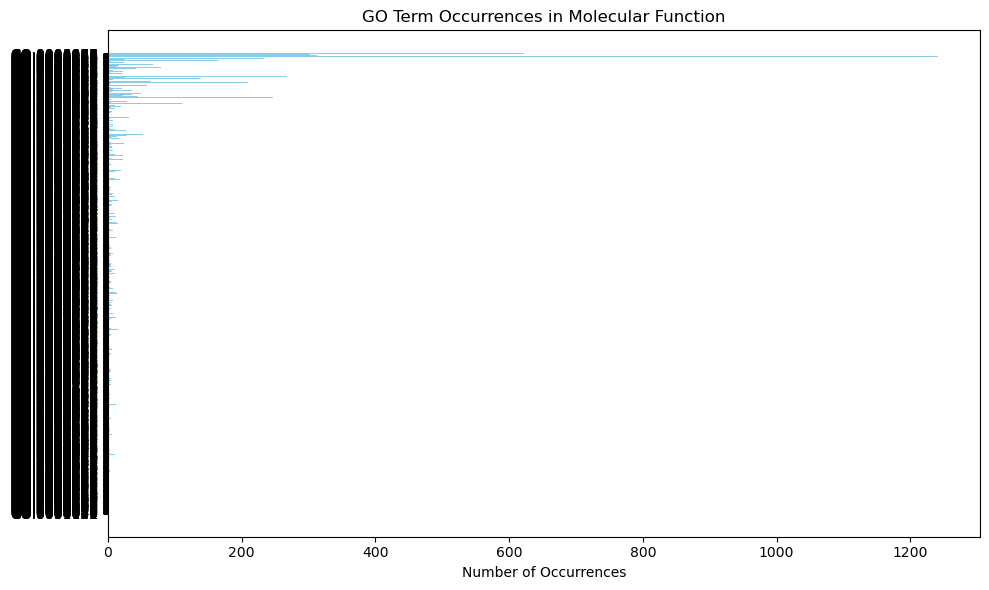

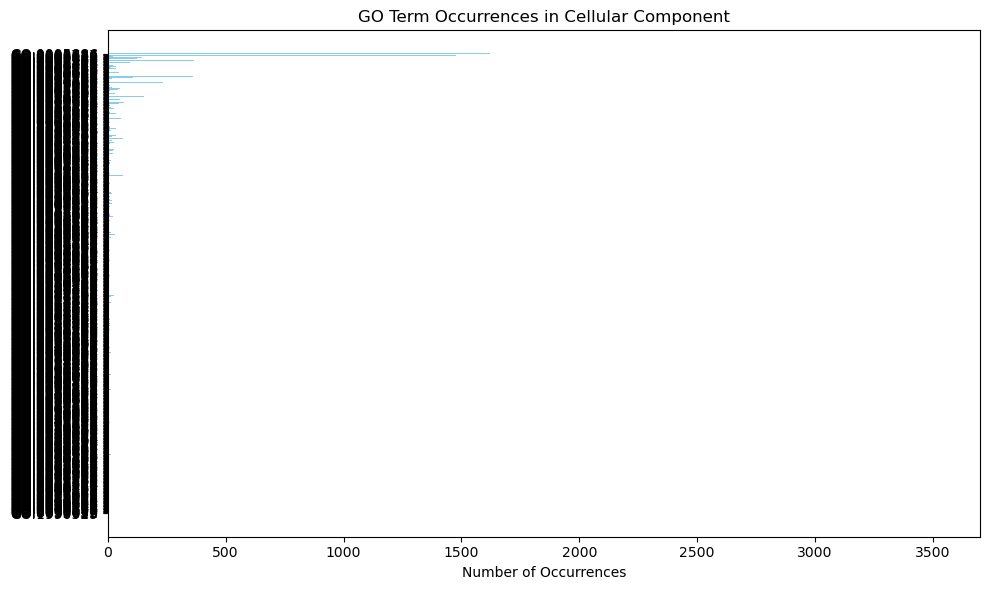

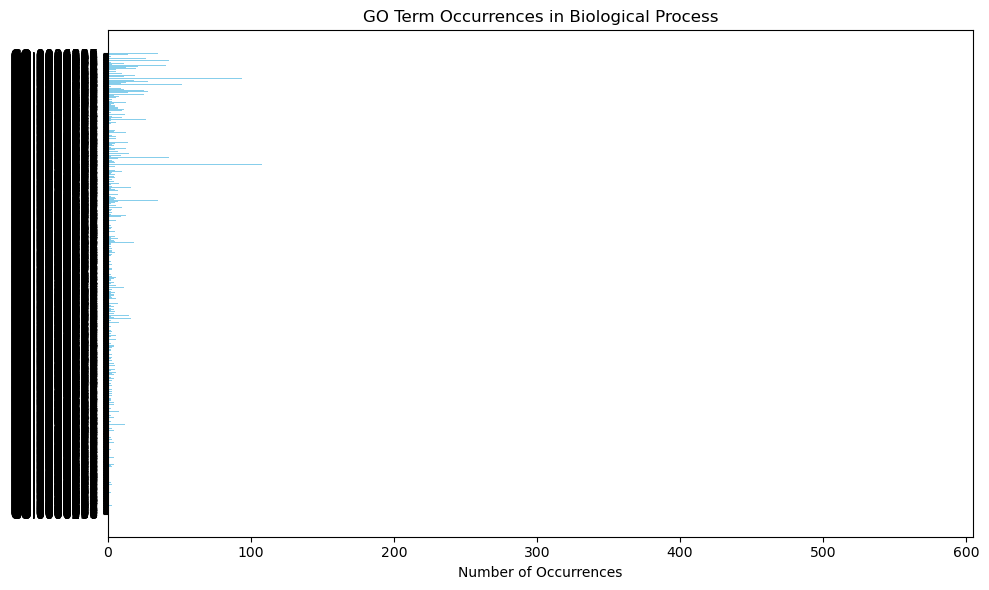

In [ ]:
def make_plot_of_go_counts(go_dict, category_name, top_x=10):
    # sort and plot only top X
    go_dict = dict(sorted(go_dict.items(), key=lambda item: item[1], reverse=True)[:top_x])
    go_ids = list(go_dict.keys())
    counts = list(go_dict.values())

    plt.figure(figsize=(10, 6))
    plt.barh(go_ids, counts, color='skyblue')
    plt.xlabel('Number of Occurrences')
    plt.title(f'GO Term Occurrences in {category_name}')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts on top
    plt.tight_layout()
    plt.show()
